In [13]:
# Import Required Libraries
import re
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, make_scorer
import matplotlib.pyplot as plt
import joblib
import numpy as np

In [3]:
# --- Data Loading and Initial Exploration ---

# Load dataset
df = pd.read_csv(r'C:/Users/Thinkpad T480/OneDrive\Documents/GitHub/CyberShield-Phishing-Email-Detector/datasets/Phishing_Email.csv')
# Check column names first
print(df.columns)

# Drop useless column
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
    
# Standardize column names
df.columns = ['message', 'label']

print("First 5 rows of the dataset:")
print(df.head())

# Download stopwords if not already done
print("\nDownloading NLTK stopwords...")
try:
    nltk.data.find('corpora/stopwords')
except nltk.downloader.DownloadError:
    nltk.download('stopwords')
print("Stopwords check complete.")

# Get the number of rows and columns
print(f"\nNumber of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

# Get data types
print("\nDataFrame Info:")
df.info()

# Checking Null values
print("\nNull values per column:")
print(df.isnull().sum())

# Checking Statistics
print("\nDataset Statistics:")
print(df.describe())

Index(['Unnamed: 0', 'Email Text', 'Email Type'], dtype='object')
First 5 rows of the dataset:
                                             message           label
0  re : 6 . 1100 , disc : uniformitarianism , re ...      Safe Email
1  the other side of * galicismos * * galicismo *...      Safe Email
2  re : equistar deal tickets are you still avail...      Safe Email
3  \nHello I am your hot lil horny toy.\n    I am...  Phishing Email
4  software at incredibly low prices ( 86 % lower...  Phishing Email

Stopwords check complete.

Number of rows: 18650
Number of columns: 2

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18650 entries, 0 to 18649
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   message  18634 non-null  object
 1   label    18650 non-null  object
dtypes: object(2)
memory usage: 291.5+ KB

Null values per column:
message    16
label       0
dtype: int64

Dataset Statistics:
       message    

In [6]:
# Drop missing values
df = df.dropna(subset=['message']).reset_index(drop=True)

# Convert labels → phishing system format
df['label'] = df['label'].replace({
    'Safe Email': 0,
    'Phishing Email': 1
})

print(df['label'].value_counts())

label
0    11322
1     7312
Name: count, dtype: int64


C:\Users\Thinkpad T480\AppData\Local\Temp\ipykernel_7924\3800769794.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['label'] = df['label'].replace({


In [7]:
# --- Text Preprocessing ---

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def clean_text(text):
    if pd.isna(text):
        return ""

    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', ' url ', text)
    text = re.sub(r'\d+', ' number ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)

    tokens = text.split()

    important_words = {
        "verify", "password", "bank", "account",
        "login", "secure", "urgent", "click",
        "confirm", "suspended"
    }

    tokens = [
        w for w in tokens
        if w not in stop_words or w in important_words
    ]

    tokens = [stemmer.stem(w) for w in tokens]

    return " ".join(tokens)

df['cleaned_message'] = df['message'].apply(clean_text)

In [8]:
# --- Feature Extraction ---

tfidf = TfidfVectorizer(
    max_features=6000,
    ngram_range=(1, 2)   # captures phrases like "login account"
)

X = tfidf.fit_transform(df['cleaned_message'])
y = df['label']

In [15]:
# --- Data Splitting and Resampling ---
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Use original training data directly
X_resampled = X_train
y_resampled = y_train

print(f"\nOriginal training set shape: {X_train.shape}, {y_train.shape}")
print(f"Resampled training set shape: {X_resampled.shape}, {y_resampled.shape}")
print(f"Resampled class distribution: {pd.Series(y_resampled).value_counts()}")



Original training set shape: (14907, 6000), (14907,)
Resampled training set shape: (14907, 6000), (14907,)
Resampled class distribution: label
0    9057
1    5850
Name: count, dtype: int64


In [18]:
# --- Model Training and Evaluation with Hyperparameter Tuning ---

# Create custom scorer for phishing email detection
f1_phishing_scorer = make_scorer(
    f1_score,
    pos_label=1
)

# Define models and their parameter grids for GridSearchCV
models_and_params = {
    "Naive Bayes": {
        'model': MultinomialNB(),
        'params': {'alpha': [0.1, 0.5, 1.0, 1.5, 2.0]} # Smoothing parameter
    },
    "Logistic Regression": {
        'model': LogisticRegression(max_iter=1000, solver='liblinear'), # 'liblinear' is good for small datasets and L1/L2 penalties
        'params': {'C': [0.1, 1.0, 10.0, 100.0], 'penalty': ['l1', 'l2']} # Regularization strength and type
    },
    "SVM": {
        'model': LinearSVC(max_iter=2000, dual=False), # Added dual=False for sparse data and older sklearn versions
        'params': {'C': [0.1, 1.0, 10.0, 100.0]} # Regularization strength
    }
}

results = []
trained_models = {}
best_model_name = None
best_model = None
best_f1_score = -1

for name, mp in models_and_params.items():
    print(f"\nTraining and tuning {name}...")
    grid_search = GridSearchCV(mp['model'], mp['params'], cv=5, scoring=f1_phishing_scorer, n_jobs=-1, verbose=1)
    grid_search.fit(X_resampled, y_resampled)

    best_estimator = grid_search.best_estimator_
    y_pred = best_estimator.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    pos_label=1
)

recall = recall_score(
    y_test,
    y_pred,
    pos_label=1
)

f1 = f1_score(
    y_test,
    y_pred,
    pos_label=1
)

print(f"\n{name} Results (Best Parameters: {grid_search.best_params_}):")
print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))
results.append({
            'Model': name,
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1
        })
trained_models[name] = best_estimator # Store the best estimator

        # Track the best model based on F1-score for 'spam'
if f1 > best_f1_score:
            best_f1_score = f1
            best_model_name = name

print(f"\nBest performing model for phishing detection: {best_model_name}")


Training and tuning Naive Bayes...
Fitting 5 folds for each of 5 candidates, totalling 25 fits

Training and tuning Logistic Regression...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Training and tuning SVM...
Fitting 5 folds for each of 4 candidates, totalling 20 fits

SVM Results (Best Parameters: {'C': 1.0}):
Accuracy: 0.9656560236114837
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      2265
           1       0.94      0.98      0.96      1462

    accuracy                           0.97      3727
   macro avg       0.96      0.97      0.96      3727
weighted avg       0.97      0.97      0.97      3727


Best performing model for phishing detection: SVM


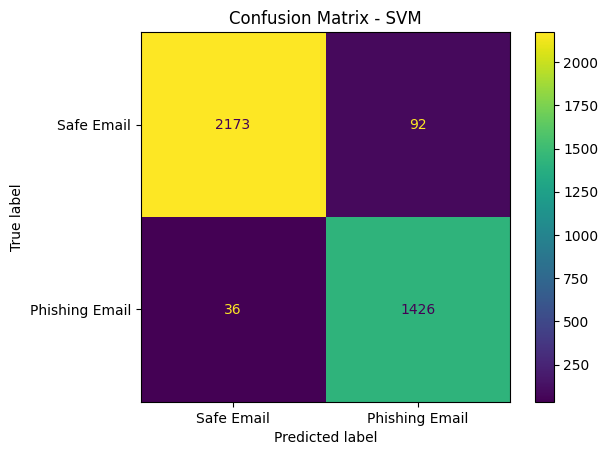


Model Comparison Table:


,Model,Accuracy,Precision,Recall,F1-Score
0,SVM,0.965656,0.939394,0.975376,0.957047


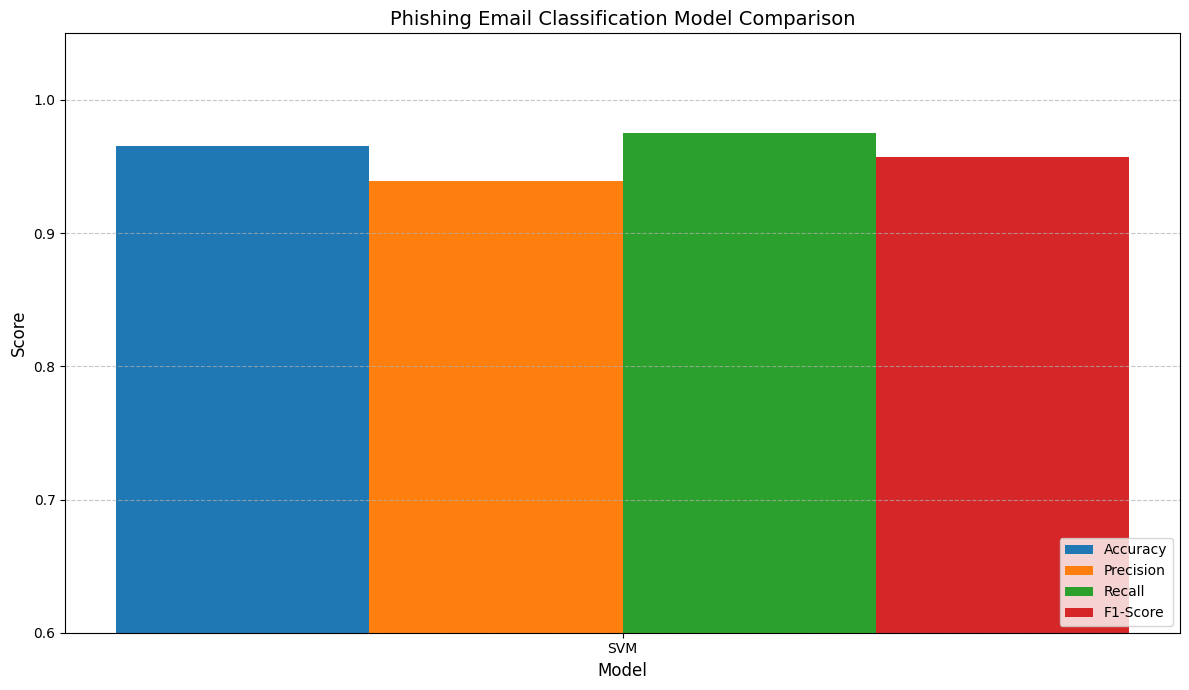

In [19]:
# --- Visualization ---

# Plot Confusion Matrix for each model
for name, model_obj in trained_models.items():
    y_pred = model_obj.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Safe Email', 'Phishing Email'])
    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

# Create comparison table
comparison = pd.DataFrame(results)
print("\nModel Comparison Table:")
display(comparison)

# Plotting comparison bar chart
models_for_plot = comparison['Model'].tolist()
accuracy_for_plot = comparison['Accuracy'].tolist()
precision_for_plot = comparison['Precision'].tolist()
recall_for_plot = comparison['Recall'].tolist()
f1_score_for_plot = comparison['F1-Score'].tolist()

bar_width = 0.2
x = np.arange(len(models_for_plot)) # Use numpy.arange for better bar positioning

plt.figure(figsize=(12, 7)) # Increased figure size
plt.bar(x - 1.5 * bar_width, accuracy_for_plot, width=bar_width, label='Accuracy')
plt.bar(x - 0.5 * bar_width, precision_for_plot, width=bar_width, label='Precision')
plt.bar(x + 0.5 * bar_width, recall_for_plot, width=bar_width, label='Recall')
plt.bar(x + 1.5 * bar_width, f1_score_for_plot, width=bar_width, label='F1-Score')

plt.xlabel('Model', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Phishing Email Classification Model Comparison', fontsize=14)
plt.xticks(ticks=x, labels=models_for_plot, rotation=0, fontsize=10) # No rotation needed for 3 models
plt.ylim(0.6, 1.05)
plt.legend(loc='lower right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [24]:
# --- Model Saving ---
import os
# Create models folder if it doesn't exist
model_path = r'C:\Users\Thinkpad T480\OneDrive\Documents\GitHub\CyberShield-Phishing-Email-Detector\app\models'

os.makedirs(model_path, exist_ok=True)

# Save TF-IDF vectorizer
joblib.dump(
    tfidf,
    os.path.join(
        model_path,
        'phishing_tfidf_vectorizer.joblib'
    )
)

# Save trained models
for name, model_obj in trained_models.items():

    filename = (
        f"phishing_"
        f"{name.lower().replace(' ', '_')}_model.joblib"
    )

    joblib.dump(
        model_obj,
        os.path.join(model_path, filename)
    )

print("Models saved successfully in app/models/")

Models saved successfully in app/models/
